In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# We will use a built-in toy dataset or a sampled version for speed
from sklearn.datasets import make_blobs

# Creating synthetic 'Normal' data and 'Anomalies'
X, _ = make_blobs(n_samples=1000, centers=1, cluster_std=2, random_state=42)
anomalies = np.random.uniform(low=-15, high=15, size=(50, 2))
data = np.vstack([X, anomalies])

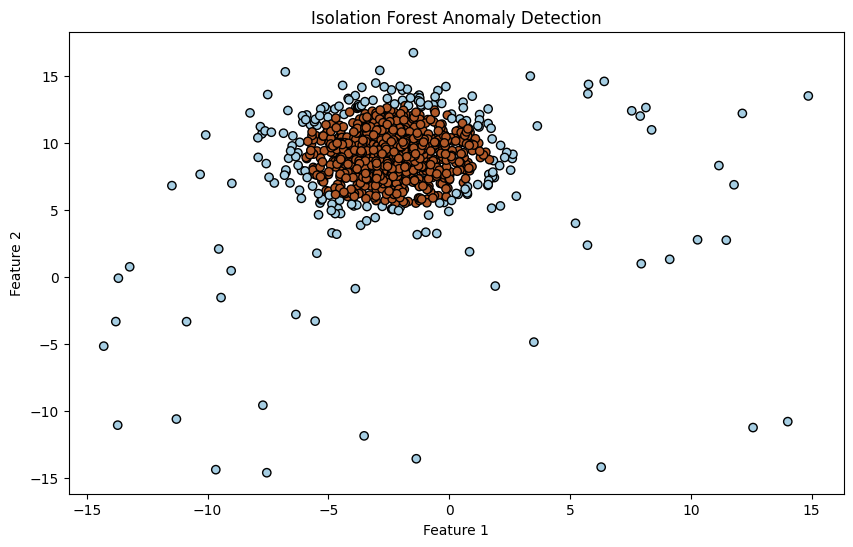

In [15]:
# Initialize the model
model = IsolationForest(contamination=0.20, random_state=42)

# Fit and Predict (-1 for outlier, 1 for inlier)
preds = model.fit_predict(data)

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], c=preds, cmap='Paired', edgecolors='k')
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [16]:
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
import pandas as pd

# 1. Fetch the 10% subset
print("Fetching data... (this may take a few seconds)")
data = fetch_kddcup99(as_frame=True, percent10=True)
df = data.frame
df['target'] = data.target # Add the target column to the DataFrame

# 2. Preprocessing
# KDDcup99 has categorical columns (protocol, service, flag).
# Isolation Forest needs numbers, so we'll encode them.
cat_cols = ['protocol_type', 'service', 'flag']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# The 'labels' column tells us if it's 'normal.' or an attack type.
# We strip the byte strings for easier reading.
df['labels'] = df['target'].apply(lambda x: x.decode('utf-8'))
X = df.drop(['target', 'labels'], axis=1)

# 3. Define 'Ground Truth' for evaluation
# In real life, we wouldn't know this! But here we use it to check our work.
y_true = df['labels'].apply(lambda x: -1 if x != 'normal.' else 1)

# 4. Train Isolation Forest
# We assume about 2% of the traffic is anomalous (malicious)
iso_forest = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
df['anomaly_score'] = iso_forest.fit_predict(X)

# 5. Review the 'Hits'
# -1 = Model thinks it's an attack | 1 = Model thinks it's normal
print("\n--- Model Predictions vs. Actual Labels ---")
print(df[['labels', 'anomaly_score']].value_counts().head(10))

Fetching data... (this may take a few seconds)

--- Model Predictions vs. Actual Labels ---
labels        anomaly_score
smurf.         1               280790
neptune.       1               107137
normal.        1                90799
              -1                 6479
back.          1                 1523
satan.        -1                 1442
ipsweep.       1                 1152
warezclient.   1                  961
teardrop.      1                  946
portsweep.    -1                  860
Name: count, dtype: int64


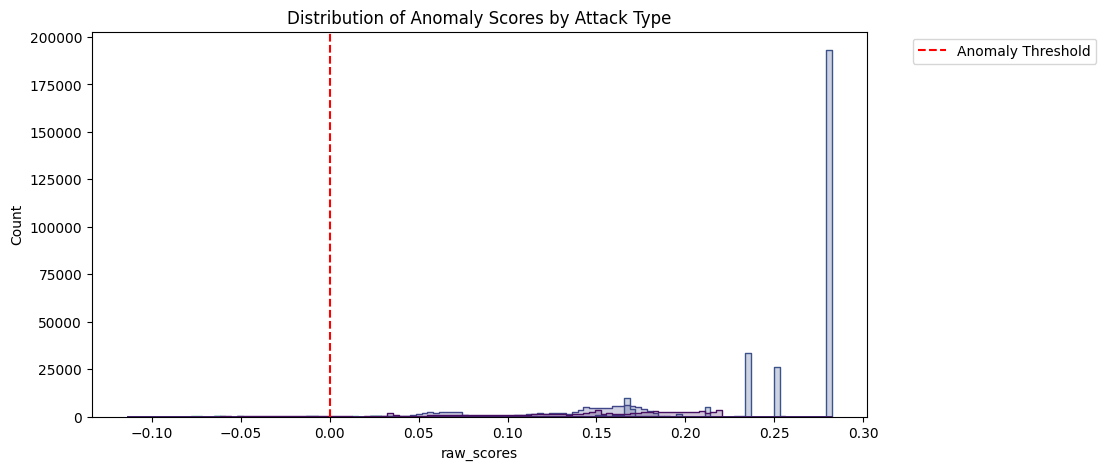

In [6]:
# Get the raw scores (lower/more negative = more anomalous)
df['raw_scores'] = iso_forest.decision_function(X)

# Plot the distribution
plt.figure(figsize=(10,5))
sns.histplot(df, x='raw_scores', hue='labels', element='step', palette='viridis')
plt.axvline(x=0, color='r', linestyle='--', label='Anomaly Threshold')
plt.title("Distribution of Anomaly Scores by Attack Type")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [8]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Log Transform skewed numerical columns
# We add +1 to avoid log(0) which is undefined
skewed_cols = ['src_bytes', 'dst_bytes', 'duration']
for col in skewed_cols:
    df[col + '_log'] = np.log1p(df[col].astype(float))

# 2. Creating a 'Traffic Intensity' feature
# Combined bytes might show a 'heavy' connection better than separate ones
df['total_bytes_log'] = np.log1p(df['src_bytes'].astype(float) + df['dst_bytes'].astype(float))

# 3. Scaling all features to [0, 1]
scaler = MinMaxScaler()
# Selecting only our new engineered features + some originals
features_to_use = [col + '_log' for col in skewed_cols] + ['total_bytes_log', 'count', 'srv_count']
X_engineered = scaler.fit_transform(df[features_to_use])

print("Original Features Shape:", X.shape)
print("Engineered Features Shape:", X_engineered.shape)

Original Features Shape: (494021, 41)
Engineered Features Shape: (494021, 6)
